In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import EditedNearestNeighbours
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf
import pickle
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Input,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dot
from tensorflow.keras.layers import Lambda
from tensorflow.keras import backend as K
import keras
import random
import numpy as np
import os
from PIL import Image
from tensorflow.keras.utils import to_categorical

2024-06-08 14:11:40.487716: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-08 14:11:40.487835: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-08 14:11:40.685931: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
def load_images_from_folder(folder):
    images = []
    labels = []
    for class_label, class_name in enumerate(sorted(os.listdir(folder))):
        class_folder = os.path.join(folder, class_name)
        for filename in os.listdir(class_folder):
            img_path = os.path.join(class_folder, filename)
            img = Image.open(img_path)
            img = img.resize((64, 64))  
            img = np.array(img)
            if img is not None:
                images.append(img)
                labels.append(class_label)
    return np.array(images), np.array(labels)

# Assuming your dataset is stored in a folder called 'dataset'
dataset_folder = '/kaggle/input/paddydoctormedium'

# Load images and labels from the dataset folder
x_data, y_data = load_images_from_folder(dataset_folder)

# Shuffle the data
random_indices = np.random.permutation(len(x_data))
x_data = x_data[random_indices]
y_data = y_data[random_indices]

# Split the data into training and testing sets (assuming 80-20 split)
split_idx = int(0.8 * len(x_data))
x_train, x_test = x_data[:split_idx], x_data[split_idx:]
y_train, y_test = y_data[:split_idx], y_data[split_idx:]

# Normalize the pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the images
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [4]:
borderline_smote = SMOTE(random_state=42)
x_train_bls, y_train_bls = borderline_smote.fit_resample(x_train, y_train)

In [5]:
x_train_bls = x_train_bls.astype('float32')
x_train_bls /= 255
x_train_bls = x_train_bls.reshape((len(x_train_bls), np.prod(x_train_bls.shape[1:])))
x_test = x_test.astype('float32')
x_test /= 255
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [6]:
num_classes = len(np.unique(y_train_bls))
y_train_one_hot = to_categorical(y_train_bls, num_classes)
y_test_one_hot = to_categorical(y_test, num_classes)

In [7]:
x_train_bls = x_train_bls.reshape(-1, 64, 64, 3)
x_test = x_test.reshape(-1, 64, 64, 3)

# Octave Conv

In [8]:
from keras.layers import Conv2D, AveragePooling2D, UpSampling2D
from keras.layers import add


def initial_octconv(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                    alpha=0.5, padding='same', dilation=None, bias=False):
    """
    Initializes the Octave Convolution architecture.

    Accepts a single input tensor, and returns a pair of tensors.
    The first tensor is the high frequency pathway.
    The second tensor is the low frequency pathway.

    # Arguments:
        ip: keras tensor.
        filters: number of filters in conv layer.
        kernel_size: conv kernel size.
        strides: strides of the conv.
        alpha: float between [0, 1]. Defines the ratio of filters
            allocated to the high frequency and low frequency
            branches of the octave conv.
        padding: padding mode.
        dilation: dilation conv kernel.
        bias: bool, whether to use bias or not.

    # Returns:
        a pair of tensors:
            - x_high: high frequency pathway.
            - x_low: low frequency pathway.
    """
    if dilation is None:
        dilation = (1, 1)

    high_low_filters = int(alpha * filters)
    high_high_filters = filters - high_low_filters

    if strides[0] > 1:
        ip = AveragePooling2D()(ip)

    # High path
    x_high = Conv2D(high_high_filters, kernel_size, padding=padding,
                    dilation_rate=dilation, use_bias=bias,
                    kernel_initializer='he_normal')(ip)

    # Low path
    x_high_low = AveragePooling2D(pool_size=(2, 2))(ip)
    x_low = Conv2D(high_low_filters, kernel_size, padding=padding,
                   dilation_rate=dilation, use_bias=bias,
                   kernel_initializer='he_normal')(x_high_low)

    return x_high, x_low


def final_octconv(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', dilation=None, bias=False):
    """
    Ends the Octave Convolution architecture.

    Accepts two input tensors, and returns a single output tensor.
    The first input tensor is the high frequency pathway.
    The second input tensor is the low frequency pathway.

    # Arguments:
        ip_high: keras tensor.
        ip_low: keras tensor.
        filters: number of filters in conv layer.
        kernel_size: conv kernel size.
        strides: strides of the conv.
        padding: padding mode.
        dilation: dilation conv kernel.
        bias: bool, whether to use bias or not.

    # Returns:
        a single Keras tensor:
            - x_high: The merged high frequency pathway.
    """
    if dilation is None:
        dilation = (1, 1)

    if strides[0] > 1:
        avg_pool = AveragePooling2D(pool_size=(2, 2))

        ip_high = avg_pool(ip_high)
        ip_low = avg_pool(ip_low)

    # High path
    x_high_high = Conv2D(filters, kernel_size, padding=padding,
                         dilation_rate=dilation, use_bias=bias,
                         kernel_initializer='he_normal')(ip_high)

    # Low path
    x_low_high = Conv2D(filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(ip_low)

    x_low_high = UpSampling2D(interpolation='nearest')(x_low_high)

    # Merge paths
    x = add([x_high_high, x_low_high])

    return x


def octconv_block(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                  alpha=0.5, padding='same', dilation=None, bias=False):
    """
    Constructs an Octave Convolution block.

    Accepts a pair of input tensors, and returns a pair of tensors.
    The first tensor is the high frequency pathway for both ip/op.
    The second tensor is the low frequency pathway for both ip/op.

    # Arguments:
        ip_high: keras tensor.
        ip_low: keras tensor.
        filters: number of filters in conv layer.
        kernel_size: conv kernel size.
        strides: strides of the conv.
        alpha: float between [0, 1]. Defines the ratio of filters
            allocated to the high frequency and low frequency
            branches of the octave conv.
        padding: padding mode.
        dilation: dilation conv kernel.
        bias: bool, whether to use bias or not.

    # Returns:
        a pair of tensors:
            - x_high: high frequency pathway.
            - x_low: low frequency pathway.
    """
    if dilation is None:
        dilation = (1, 1)

    low_low_filters = high_low_filters = int(alpha * filters)
    high_high_filters = low_high_filters = filters - low_low_filters

    avg_pool = AveragePooling2D(pool_size=(2, 2))

    if strides[0] > 1:
        ip_high = avg_pool(ip_high)
        ip_low = avg_pool(ip_low)

    # High path
    x_high_high = Conv2D(high_high_filters, kernel_size, padding=padding,
                         dilation_rate=dilation, use_bias=bias,
                         kernel_initializer='he_normal')(ip_high)

    x_low_high = Conv2D(low_high_filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(ip_low)
    x_low_high = UpSampling2D(interpolation='nearest')(x_low_high)

    # Low path
    x_low_low = Conv2D(low_low_filters, kernel_size, padding=padding,
                       dilation_rate=dilation, use_bias=bias,
                       kernel_initializer='he_normal')(ip_low)

    x_high_low = avg_pool(ip_high)
    x_high_low = Conv2D(high_low_filters, kernel_size, padding=padding,
                        dilation_rate=dilation, use_bias=bias,
                        kernel_initializer='he_normal')(x_high_low)

    # Merge paths
    x_high = add([x_high_high, x_low_high])
    x_low = add([x_low_low, x_high_low])

    return x_high, x_low


if __name__ == '__main__':

    visualize_model = True

    from keras.models import Model
    from keras.layers import Input

    ip = Input(shape=(32, 32, 3))

    xh, xl = initial_octconv(ip, filters=48)

    xh, xl = octconv_block(xh, xl, filters=64)
    xh, xl = octconv_block(xh, xl, filters=96, strides=(2, 2))

    x = final_octconv(xh, xl, filters=10)

    model = Model(ip, x)

In [9]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'



from keras.layers import ReLU, BatchNormalization
from keras import backend as K



def initial_oct_conv_bn_relu(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                             alpha=0.5, padding='same', dilation=None, bias=False,
                             activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x_high, x_low = initial_octconv(ip, filters, kernel_size, strides, alpha,
                                    padding, dilation, bias)

    relu = ReLU()
    x_high = BatchNormalization(axis=channel_axis)(x_high)
    if activation:
        x_high = relu(x_high)

    x_low = BatchNormalization(axis=channel_axis)(x_low)
    if activation:
        x_low = relu(x_low)

    return x_high, x_low


def final_oct_conv_bn_relu(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                           padding='same', dilation=None, bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = final_octconv(ip_high, ip_low, filters, kernel_size, strides,
                      padding, dilation, bias)

    x = BatchNormalization(axis=channel_axis)(x)
    if activation:
        x = ReLU()(x)

    return x


def oct_conv_bn_relu(ip_high, ip_low, filters, kernel_size=(3, 3), strides=(1, 1),
                     alpha=0.5, padding='same', dilation=None, bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x_high, x_low = octconv_block(ip_high, ip_low, filters, kernel_size, strides, alpha,
                                  padding, dilation, bias)

    relu = ReLU()
    x_high = BatchNormalization(axis=channel_axis)(x_high)
    if activation:
        x_high = relu(x_high)

    x_low = BatchNormalization(axis=channel_axis)(x_low)
    if activation:
        x_low = relu(x_low)

    return x_high, x_low

In [10]:
import os
from keras.layers import BatchNormalization
from keras.layers import Conv2D
from keras.layers import Dense
from keras.layers import GlobalAveragePooling2D
from keras.layers import GlobalMaxPooling2D
from keras.layers import Input
from keras.layers import MaxPool2D
from keras.layers import ReLU
from keras.layers import add
from keras.models import Model
from keras.utils import get_source_inputs

from keras import backend as K
from keras_applications.imagenet_utils import _obtain_input_shape



def _conv_block(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                padding='same', bias=False):
    x = Conv2D(filters, kernel_size, strides=strides, padding=padding, use_bias=bias,
               kernel_initializer='he_normal')(ip)

    return x


def _conv_bn_relu(ip, filters, kernel_size=(3, 3), strides=(1, 1),
                  padding='same', bias=False, activation=True):

    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = _conv_block(ip, filters, kernel_size, strides, padding, bias)
    x = BatchNormalization(axis=channel_axis)(x)
    if activation:
        x = ReLU()(x)

    return x


def _octresnet_bottleneck_block(ip, filters, alpha=0.5, strides=(1, 1),
                                downsample_shortcut=False, first_block=False,
                                expansion=4):

    if first_block:
        x_high_res, x_low_res = initial_oct_conv_bn_relu(ip, filters, kernel_size=(1, 1),
                                                         alpha=alpha)

        x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(3, 3),
                                         strides=strides, alpha=alpha)

    else:
        x_high_res, x_low_res = ip
        x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(1, 1),
                                         alpha=alpha)

        x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters, kernel_size=(3, 3),
                                         strides=strides, alpha=alpha)

    final_out_filters = int(filters * expansion)
    x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters=final_out_filters,
                                     kernel_size=(1, 1), alpha=alpha, activation=False)

    if downsample_shortcut:
        x_high_res, x_low_res = oct_conv_bn_relu(x_high_res, x_low_res,
                                                 final_out_filters, kernel_size=(1, 1),
                                                 strides=strides, alpha=alpha,
                                                 activation=False)

    x_high = add([x_high, x_high_res])
    x_low = add([x_low, x_low_res])

    x_high = ReLU()(x_high)
    x_low = ReLU()(x_low)

    return x_high, x_low


def _octresnet_final_bottleneck_block(ip, filters, alpha=0.5, strides=(1, 1),
                                      downsample_shortcut=False,
                                      expansion=4):

    x_high_res, x_low_res = ip

    x_high, x_low = oct_conv_bn_relu(x_high_res, x_low_res, filters, kernel_size=(1, 1),
                                     alpha=alpha)

    x_high, x_low = oct_conv_bn_relu(x_high, x_low, filters, kernel_size=(3, 3),
                                     strides=strides, alpha=alpha)

    final_filters = int(filters * expansion)
    x_high = final_oct_conv_bn_relu(x_high, x_low, final_filters, kernel_size=(1, 1),
                                    activation=False)

    if downsample_shortcut:
        x_high_res = final_oct_conv_bn_relu(x_high_res, x_low_res, final_filters, kernel_size=(1, 1),
                                            strides=strides, activation=False)

    x = add([x_high, x_high_res])
    x = ReLU()(x)

    return x


def _bottleneck_original(ip, filters, strides=(1, 1), downsample_shortcut=False,
                         expansion=4):

    final_filters = int(filters * expansion)

    shortcut = ip

    x = _conv_bn_relu(ip, filters, kernel_size=(1, 1))
    x = _conv_bn_relu(x, filters, kernel_size=(3, 3), strides=strides)
    x = _conv_bn_relu(x, final_filters, kernel_size=(1, 1), activation=False)

    if downsample_shortcut:
        shortcut = _conv_block(shortcut, final_filters, kernel_size=(1, 1),
                               strides=strides)

    x = add([x, shortcut])
    x = ReLU()(x)

    return x


def OctaveResNet(layers,
                 include_top=True,
                 weights=None,
                 input_tensor=None,
                 input_shape=None,
                 pooling=None,
                 classes=1000,
                 alpha=0.5,
                 expansion=1,
                 initial_filters=64,
                 initial_strides=False,
                 **kwargs):
    """ Instantiates a Octave ResNet architecture.

    # Arguments
        layers: list of integers defining the depth of the network and
            the number of octave conv blocks per level of the
            network.
        include_top: whether to include the fully-connected
            layer at the top of the network.
        weights: one of `None` (random initialization),
              'imagenet' (pre-training on ImageNet),
              or the path to the weights file to be loaded.
        input_tensor: optional Keras tensor
            (i.e. output of `layers.Input()`)
            to use as image input for the model.
        input_shape: optional shape tuple, only to be specified
            if `include_top` is False (otherwise the input shape
            has to be `(224, 224, 3)` (with `'channels_last'` data format)
            or `(3, 224, 224)` (with `'channels_first'` data format).
            It should have exactly 3 inputs channels,
            and width and height should be no smaller than 32.
            E.g. `(200, 200, 3)` would be one valid value.
        pooling: optional pooling mode for feature extraction
            when `include_top` is `False`.
            - `None` means that the output of the model will be
                the 4D tensor output of the
                last convolutional layer.
            - `avg` means that global average pooling
                will be applied to the output of the
                last convolutional layer, and thus
                the output of the model will be a 2D tensor.
            - `max` means that global max pooling will
                be applied.
        classes: optional number of classes to classify images
            into, only to be specified if `include_top` is True, and
            if no `weights` argument is specified.
        alpha: float between [0, 1]. Defines the ratio of filters
            allocated to the high frequency and low frequency
            branches of the octave conv.
        expansion: int/float. Multiplicative factor to increase the
            number of filters in each octave block.
        initial_filters: number of filters in the first convolution
            layer. Determines how many parameters the network will
            have.
        initial_strides: bool to determine whether to apply a strided
            convolution and max pooling before any octave conv
            block. Set to True for ImageNet models and False for
            CIFAR models.

    # Returns
        A Keras model instance.

    # Raises
        ValueError: in case of invalid argument for `weights`,
            or invalid input shape.
`       ValueError: If `alpha` is < 0 or > 1.
        ValueError: If `layers` is not a list or a tuple
            of integers.
    """

    if not (weights in {'imagenet', None} or os.path.exists(weights)):
        raise ValueError('The `weights` argument should be either '
                         '`None` (random initialization), `imagenet` '
                         '(pre-training on ImageNet), '
                         'or the path to the weights file to be loaded.')

    if weights == 'imagenet' and include_top and classes != 1000:
        raise ValueError('If using `weights` as `"imagenet"` with `include_top`'
                         ' as true, `classes` should be 1000')

    if alpha < 0. or alpha > 1.:
        raise ValueError('`alpha` must be between 0 and 1. Current alpha = '
                         '%f' % alpha)

    if type(layers) not in [list, tuple]:
        raise ValueError('`layers` must be a list/tuple of integers. '
                         'Current layers = ', layers)

    # Force convert all layer values to integers
    layers = [int(x) for x in layers]

    # Determine proper input shape
    input_shape = _obtain_input_shape(input_shape,
                                      default_size=224,
                                      min_size=32,
                                      data_format=K.image_data_format(),
                                      require_flatten=include_top,
                                      weights=weights)

    if input_tensor is None:
        img_input = Input(shape=input_shape)
    else:
        if not K.is_keras_tensor(input_tensor):
            img_input = Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    if initial_strides:
        initial_strides = (2, 2)

    else:
        initial_strides = (1, 1)

    x = _conv_bn_relu(img_input, filters=64, kernel_size=(7, 7), strides=initial_strides)

    if initial_strides:
        x = MaxPool2D((3, 3), strides=(2, 2), padding='same')(x)

    num_filters = initial_filters
    num_blocks = len(layers)

    for i in range(num_blocks - 1):
        for j in range(layers[i]):
            if j == 0:
                strides = (2, 2)
                downsample_shortcut = True

            else:
                strides = (1, 1)
                downsample_shortcut = False

            # first block has no downsample, no shortcut
            if i == 0 and j == 0:
                first_block = True
                strides = (1, 1)
                downsample_shortcut = True

            else:
                first_block = False

            x = _octresnet_bottleneck_block(x, num_filters, alpha, strides, downsample_shortcut,
                                            first_block, expansion)

        # double number of filters per block
        num_filters *= 2

    # final block
    for j in range(layers[-1]):
        if j == 0:
            strides = (2, 2)
            x = _octresnet_final_bottleneck_block(x, num_filters, alpha, strides,
                                                  downsample_shortcut=True, expansion=expansion)

        else:
            strides = (1, 1)
            x = _bottleneck_original(x, num_filters, strides, expansion=expansion)

    if include_top:
        x = GlobalAveragePooling2D(name='avg_pool')(x)
        x = Dense(classes, activation='softmax', name='fc')(x)
    else:
        if pooling == 'avg':
            x = GlobalAveragePooling2D(name='avg_pool')(x)
        elif pooling == 'max':
            x = GlobalMaxPooling2D(name='max_pool')(x)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = get_source_inputs(input_tensor)
    else:
        inputs = img_input

    model = Model(inputs, x, name='OctaveResNet')

    return model


def OctaveResNet50(include_top=True,
                   weights=None,
                   input_tensor=None,
                   input_shape=None,
                   pooling=None,
                   classes=1000,
                   alpha=0.5,
                   expansion=4,
                   initial_filters=64,
                   initial_strides=True,
                   **kwargs):

    return OctaveResNet([3, 4, 6, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


def OctaveResNet101(include_top=True,
                    weights=None,
                    input_tensor=None,
                    input_shape=None,
                    pooling=None,
                    classes=1000,
                    alpha=0.5,
                    expansion=4,
                    initial_filters=64,
                    initial_strides=True,
                    **kwargs):

    return OctaveResNet([3, 4, 23, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


def OctaveResNet152(include_top=True,
                    weights=None,
                    input_tensor=None,
                    input_shape=None,
                    pooling=None,
                    classes=1000,
                    alpha=0.5,
                    expansion=4,
                    initial_filters=64,
                    initial_strides=True,
                    **kwargs):

    return OctaveResNet([3, 8, 36, 3],
                        include_top,
                        weights,
                        input_tensor,
                        input_shape,
                        pooling,
                        classes,
                        alpha,
                        expansion,
                        initial_filters,
                        initial_strides,
                        **kwargs)


if __name__ == '__main__':
    model = OctaveResNet50(input_shape=(256, 256, 3), classes=1000,
                           alpha=0.125, expansion=4,
                           initial_filters=64,
                           initial_strides=True)

In [11]:
model2 = OctaveResNet50(include_top=True,
                        weights=None,
                        input_tensor=None,
                        input_shape=(64,64,3),
                        pooling='avg',
                        classes=13,
                        alpha=0.125,
                        expansion=4,
                        initial_filters=64,
                        initial_strides=True)
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
from tensorflow.keras.callbacks import EarlyStopping,Callback

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.96:
            self.model.stop_training = True

# Instantiate the custom callback
callback = CustomCallback()

# Train the model 
history = model2.fit(x_train_bls,y_train_one_hot,epochs=100,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks=callback)

Epoch 1/100


I0000 00:00:1717856291.297567     177 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1717856291.485925     177 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.3881 - loss: 2.3991

W0000 00:00:1717856392.160537     178 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1717856403.552855     178 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


389/389 ━━━━━━━━━━━━━━━━━━━━ 259s 323ms/step - accuracy: 0.3883 - loss: 2.3978 - val_accuracy: 0.1199 - val_loss: 4.0512
Epoch 2/100
  1/389 ━━━━━━━━━━━━━━━━━━━━ 1:09 180ms/step - accuracy: 0.7188 - loss: 0.9178

W0000 00:00:1717856417.013541     179 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


389/389 ━━━━━━━━━━━━━━━━━━━━ 36s 92ms/step - accuracy: 0.6752 - loss: 1.1852 - val_accuracy: 0.2992 - val_loss: 91.2769
Epoch 3/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 91ms/step - accuracy: 0.7990 - loss: 0.7885 - val_accuracy: 0.7507 - val_loss: 1.1005
Epoch 4/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 91ms/step - accuracy: 0.8523 - loss: 0.5417 - val_accuracy: 0.6348 - val_loss: 1.1574
Epoch 5/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 91ms/step - accuracy: 0.8475 - loss: 0.5603 - val_accuracy: 0.7917 - val_loss: 0.6902
Epoch 6/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 91ms/step - accuracy: 0.8711 - loss: 0.4575 - val_accuracy: 0.8339 - val_loss: 0.5487
Epoch 7/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 91ms/step - accuracy: 0.9426 - loss: 0.1904 - val_accuracy: 0.8065 - val_loss: 0.6805
Epoch 8/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 91ms/step - accuracy: 0.9427 - loss: 0.2068 - val_accuracy: 0.7972 - val_loss: 1.0928
Epoch 9/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 91ms/step - accuracy: 0.9624 - loss: 0.1369 - val

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - accuracy: 0.9963 - loss: 0.0128 - val_accuracy: 0.9408 - val_loss: 0.3173
Epoch 58/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.9945 - loss: 0.0176 - val_accuracy: 0.8937 - val_loss: 0.4563
Epoch 59/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.9945 - loss: 0.0176 - val_accuracy: 0.9433 - val_loss: 0.2686
Epoch 60/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - accuracy: 0.9962 - loss: 0.0133 - val_accuracy: 0.9479 - val_loss: 0.2682
Epoch 61/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.9942 - loss: 0.0166 - val_accuracy: 0.9414 - val_loss: 0.2480
Epoch 62/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - accuracy: 0.9883 - loss: 0.0458 - val_accuracy: 0.9492 - val_loss: 0.2173
Epoch 63/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.9964 - loss: 0.0086 - val_accuracy: 0.9014 - val_loss: 0.4121
Epoch 64/100
373/389 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.9961 - loss: 0.0145

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [13]:
loss,accuracy = model2.evaluate(x_test,y_test_one_hot)
print("testing accuracy:", accuracy)

  8/102 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9457 - loss: 0.3302

W0000 00:00:1717858799.156354     177 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - accuracy: 0.9652 - loss: 0.1798
testing accuracy: 0.9670261740684509


W0000 00:00:1717858812.516790     177 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


# MobileNet

In [21]:
import warnings

from keras import backend
from keras import layers
from keras.applications import imagenet_utils
from tensorflow.keras import Model
from keras_applications.imagenet_utils import _obtain_input_shape


BASE_WEIGHT_PATH = (
    "https://storage.googleapis.com/tensorflow/keras-applications/mobilenet/"
)

def MobileNet(
    input_shape=None,
    alpha=1.0,
    depth_multiplier=1,
    dropout=1e-3,
    include_top=True,
    weights=None,
    input_tensor=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    
    if not (weights in {"imagenet", None} or file_utils.exists(weights)):
        raise ValueError(
            "The `weights` argument should be either "
            "`None` (random initialization), 'imagenet' "
            "(pre-training on ImageNet), "
            "or the path to the weights file to be loaded. "
            f"Received weights={weights}"
        )

    if weights == "imagenet" and include_top and classes != 1000:
        raise ValueError(
            "If using `weights='imagenet'` with `include_top=True`, "
            "`classes` should be 1000.  "
            f"Received classes={classes}"
        )

    # Determine proper input shape and default size.
    if input_shape is None:
        default_size = 224
    else:
        if backend.image_data_format() == "channels_first":
            rows = input_shape[1]
            cols = input_shape[2]
        else:
            rows = input_shape[0]
            cols = input_shape[1]

        if rows == cols and rows in [128, 160, 192, 224]:
            default_size = rows
        else:
            default_size = 224

    input_shape = _obtain_input_shape(
        input_shape,
        default_size=default_size,
        min_size=32,
        data_format=backend.image_data_format(),
        require_flatten=include_top,
        weights=weights,
    )

    if backend.image_data_format() == "channels_last":
        row_axis, col_axis = (0, 1)
    else:
        row_axis, col_axis = (1, 2)
    rows = input_shape[row_axis]
    cols = input_shape[col_axis]

    if weights == "imagenet":
        if depth_multiplier != 1:
            raise ValueError(
                "If imagenet weights are being loaded, "
                "depth multiplier must be 1.  "
                f"Received depth_multiplier={depth_multiplier}"
            )

        if alpha not in [0.25, 0.50, 0.75, 1.0]:
            raise ValueError(
                "If imagenet weights are being loaded, "
                "alpha can be one of"
                "`0.25`, `0.50`, `0.75` or `1.0` only.  "
                f"Received alpha={alpha}"
            )

        if rows != cols or rows not in [128, 160, 192, 224]:
            rows = 224
            warnings.warn(
                "`input_shape` is undefined or non-square, "
                "or `rows` is not in [128, 160, 192, 224]. "
                "Weights for input shape (224, 224) will be "
                "loaded as the default.",
                stacklevel=2,
            )

    if input_tensor is None:
        img_input = layers.Input(shape=input_shape)
    else:
        if not backend.is_keras_tensor(input_tensor):
            img_input = layers.Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    x = _conv_block(img_input, 32, alpha, strides=(2, 2))
    x = _depthwise_conv_block(x, 64, alpha, depth_multiplier, block_id=1)

    x = _depthwise_conv_block(
        x, 128, alpha, depth_multiplier, strides=(2, 2), block_id=2
    )
    x = _depthwise_conv_block(x, 128, alpha, depth_multiplier, block_id=3)

    x = _depthwise_conv_block(
        x, 256, alpha, depth_multiplier, strides=(2, 2), block_id=4
    )
    x = _depthwise_conv_block(x, 256, alpha, depth_multiplier, block_id=5)

    x = _depthwise_conv_block(
        x, 512, alpha, depth_multiplier, strides=(2, 2), block_id=6
    )
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=7)
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=8)
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=9)
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=10)
    x = _depthwise_conv_block(x, 512, alpha, depth_multiplier, block_id=11)

    x = _depthwise_conv_block(
        x, 1024, alpha, depth_multiplier, strides=(2, 2), block_id=12
    )
    x = _depthwise_conv_block(x, 1024, alpha, depth_multiplier, block_id=13)

    if include_top:
        x = layers.GlobalAveragePooling2D(keepdims=True)(x)
        x = layers.Dropout(dropout, name="dropout")(x)
        x = layers.Conv2D(classes, (1, 1), padding="same", name="conv_preds")(x)
        x = layers.Reshape((classes,), name="reshape_2")(x)
        x = layers.Activation(
            activation=classifier_activation, name="predictions"
        )(x)
    else:
        if pooling == "avg":
            x = layers.GlobalAveragePooling2D()(x)
        elif pooling == "max":
            x = layers.GlobalMaxPooling2D()(x)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = input_tensor
    else:
        inputs = img_input

    # Create model.
    model = Model(inputs, x, name=f"mobilenet_{alpha:0.2f}_{rows}")

    # Load weights.
    if weights == "imagenet":
        if alpha == 1.0:
            alpha_text = "1_0"
        elif alpha == 0.75:
            alpha_text = "7_5"
        elif alpha == 0.50:
            alpha_text = "5_0"
        else:
            alpha_text = "2_5"

        if include_top:
            model_name = "mobilenet_%s_%d_tf.h5" % (alpha_text, rows)
            weight_path = BASE_WEIGHT_PATH + model_name
            weights_path = tf.keras.utils.get_file(
                model_name, weight_path, cache_subdir="models"
            )
        else:
            model_name = "mobilenet_%s_%d_tf_no_top.h5" % (alpha_text, rows)
            weight_path = BASE_WEIGHT_PATH + model_name
            weights_path = tf.keras.utils.get_file(
                model_name, weight_path, cache_subdir="models"
            )
        model.load_weights(weights_path)
    elif weights is not None:
        model.load_weights(weights)

    return model


def _conv_block(inputs, filters, alpha, kernel=(3, 3), strides=(1, 1)):
    
    channel_axis = 1 if backend.image_data_format() == "channels_first" else -1
    filters = int(filters * alpha)
    x = layers.Conv2D(
        filters,
        kernel,
        padding="same",
        use_bias=False,
        strides=strides,
        name="conv1",
    )(inputs)
    x = layers.BatchNormalization(axis=channel_axis, name="conv1_bn")(x)
    return layers.ReLU(6.0, name="conv1_relu")(x)


def _depthwise_conv_block(
    inputs,
    pointwise_conv_filters,
    alpha,
    depth_multiplier=1,
    strides=(1, 1),
    block_id=1,
):
    
    channel_axis = 1 if backend.image_data_format() == "channels_first" else -1
    pointwise_conv_filters = int(pointwise_conv_filters * alpha)

    if strides == (1, 1):
        x = inputs
    else:
        x = layers.ZeroPadding2D(
            ((0, 1), (0, 1)), name="conv_pad_%d" % block_id
        )(inputs)
    x = layers.DepthwiseConv2D(
        (3, 3),
        padding="same" if strides == (1, 1) else "valid",
        depth_multiplier=depth_multiplier,
        strides=strides,
        use_bias=False,
        name="conv_dw_%d" % block_id,
    )(x)
    x = layers.BatchNormalization(
        axis=channel_axis, name="conv_dw_%d_bn" % block_id
    )(x)
    x = layers.ReLU(6.0, name="conv_dw_%d_relu" % block_id)(x)

    x = layers.Conv2D(
        pointwise_conv_filters,
        (1, 1),
        padding="same",
        use_bias=False,
        strides=(1, 1),
        name="conv_pw_%d" % block_id,
    )(x)
    x = layers.BatchNormalization(
        axis=channel_axis, name="conv_pw_%d_bn" % block_id
    )(x)
    return layers.ReLU(6.0, name="conv_pw_%d_relu" % block_id)(x)



def preprocess_input(x, data_format=None):
    return imagenet_utils.preprocess_input(
        x, data_format=data_format, mode="tf"
    )


def decode_predictions(preds, top=5):
    return imagenet_utils.decode_predictions(preds, top=top)

In [22]:
model3 = MobileNet(include_top=True,weights=None,input_tensor=None,input_shape=(64,64,3),classes=13)
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.92:
            self.model.stop_training = True

# Instantiate the custom callback
callback2 = CustomCallback()

# Train the model 
history2 = model3.fit(x_train_bls,y_train_one_hot,epochs=100,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks=callback2)

Epoch 1/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - accuracy: 0.2145 - loss: 2.3528 - val_accuracy: 0.1519 - val_loss: 2.8016
Epoch 2/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6054 - loss: 1.2127 - val_accuracy: 0.2052 - val_loss: 3.5223
Epoch 3/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7820 - loss: 0.6965 - val_accuracy: 0.4487 - val_loss: 1.9838
Epoch 4/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8571 - loss: 0.4522 - val_accuracy: 0.5082 - val_loss: 1.7723
Epoch 5/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9031 - loss: 0.3129 - val_accuracy: 0.6906 - val_loss: 1.1754
Epoch 6/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9277 - loss: 0.2337 - val_accuracy: 0.7402 - val_loss: 0.9483
Epoch 7/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9368 - loss: 0.1982 - val_accuracy: 0.6616 - val_loss: 1.3761
Epoch 8/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9510 - loss: 0.1639 -

In [24]:
loss,accuracy = model3.evaluate(x_test,y_test_one_hot)
print("testing accuracy:", accuracy)

102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9207 - loss: 0.3369
testing accuracy: 0.9238829016685486


# DenseNet

In [29]:
from keras import backend
from keras import layers
from keras.applications import imagenet_utils
from tensorflow.keras.models import Model
from keras_applications.imagenet_utils import _obtain_input_shape

BASE_WEIGHTS_PATH = (
    "https://storage.googleapis.com/tensorflow/keras-applications/densenet/"
)
DENSENET121_WEIGHT_PATH = (
    BASE_WEIGHTS_PATH + "densenet121_weights_tf_dim_ordering_tf_kernels.h5"
)
DENSENET121_WEIGHT_PATH_NO_TOP = (
    BASE_WEIGHTS_PATH
    + "densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5"
)
DENSENET169_WEIGHT_PATH = (
    BASE_WEIGHTS_PATH + "densenet169_weights_tf_dim_ordering_tf_kernels.h5"
)
DENSENET169_WEIGHT_PATH_NO_TOP = (
    BASE_WEIGHTS_PATH
    + "densenet169_weights_tf_dim_ordering_tf_kernels_notop.h5"
)
DENSENET201_WEIGHT_PATH = (
    BASE_WEIGHTS_PATH + "densenet201_weights_tf_dim_ordering_tf_kernels.h5"
)
DENSENET201_WEIGHT_PATH_NO_TOP = (
    BASE_WEIGHTS_PATH
    + "densenet201_weights_tf_dim_ordering_tf_kernels_notop.h5"
)


def dense_block(x, blocks, name):
    
    for i in range(blocks):
        x = conv_block(x, 32, name=name + "_block" + str(i + 1))
    return x


def transition_block(x, reduction, name):
    
    bn_axis = 3 if backend.image_data_format() == "channels_last" else 1
    x = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name=name + "_bn"
    )(x)
    x = layers.Activation("relu", name=name + "_relu")(x)
    x = layers.Conv2D(
        int(x.shape[bn_axis] * reduction),
        1,
        use_bias=False,
        name=name + "_conv",
    )(x)
    x = layers.AveragePooling2D(2, strides=2, name=name + "_pool")(x)
    return x


def conv_block(x, growth_rate, name):
    
    bn_axis = 3 if backend.image_data_format() == "channels_last" else 1
    x1 = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name=name + "_0_bn"
    )(x)
    x1 = layers.Activation("relu", name=name + "_0_relu")(x1)
    x1 = layers.Conv2D(
        4 * growth_rate, 1, use_bias=False, name=name + "_1_conv"
    )(x1)
    x1 = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name=name + "_1_bn"
    )(x1)
    x1 = layers.Activation("relu", name=name + "_1_relu")(x1)
    x1 = layers.Conv2D(
        growth_rate, 3, padding="same", use_bias=False, name=name + "_2_conv"
    )(x1)
    x = layers.Concatenate(axis=bn_axis, name=name + "_concat")([x, x1])
    return x


def DenseNet(
    blocks,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    
    if backend.image_data_format() == "channels_first":
        raise ValueError(
            "DenseNet does not support the channels_first image data "
            "format. Switch to channels_last by editing your local "
            "config file at ~/.keras/keras.json"
        )
    if not (weights in {"imagenet", None} or file_utils.exists(weights)):
        raise ValueError(
            "The weights argument should be either "
            "None (random initialization), imagenet "
            "(pre-training on ImageNet), "
            "or the path to the weights file to be loaded."
        )

    if weights == "imagenet" and include_top and classes != 1000:
        raise ValueError(
            'If using weights as "imagenet" with include_top'
            " as true, classes should be 1000"
        )

    # Determine proper input shape
    input_shape = _obtain_input_shape(
        input_shape,
        default_size=224,
        min_size=32,
        data_format=backend.image_data_format(),
        require_flatten=include_top,
        weights=weights,
    )

    if input_tensor is None:
        img_input = layers.Input(shape=input_shape)
    else:
        if not backend.is_keras_tensor(input_tensor):
            img_input = layers.Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    bn_axis = 3 if backend.image_data_format() == "channels_last" else 1

    x = layers.ZeroPadding2D(padding=((3, 3), (3, 3)))(img_input)
    x = layers.Conv2D(64, 7, strides=2, use_bias=False, name="conv1m1")(x)
    x = layers.BatchNormalization(
        axis=bn_axis, epsilon=1.001e-5, name="conv"
    )(x)
    x = layers.Activation("relu", name="conv1_relu")(x)
    x = layers.ZeroPadding2D(padding=((1, 1), (1, 1)))(x)
    x = layers.MaxPooling2D(3, strides=2, name="pool1")(x)

    x = dense_block(x, blocks[0], name="conv2m1")
    x = transition_block(x, 0.5, name="pool2")
    x = dense_block(x, blocks[1], name="conv3m1")
    x = transition_block(x, 0.5, name="pool3")
    x = dense_block(x, blocks[2], name="conv4m1")
    x = transition_block(x, 0.5, name="pool4")
    x = dense_block(x, blocks[3], name="conv5m1")

    x = layers.BatchNormalization(axis=bn_axis, epsilon=1.001e-5, name="bn")(x)
    x = layers.Activation("relu", name="relu")(x)

    if include_top:
        x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
        x = layers.Dense(classes, activation=classifier_activation, name="predictions")(x)
    else:
        if pooling == "avg":
            x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
        elif pooling == "max":
            x = layers.GlobalMaxPooling2D(name="max_pool")(x)

    # Ensure that the model takes into account
    # any potential predecessors of input_tensor.
    if input_tensor is not None:
        inputs = operation_utils.get_source_inputs(input_tensor)
    else:
        inputs = img_input

    # Create model.
    if blocks == [6, 12, 24, 16]:
        model = Model(inputs, x, name="densenet121")
    elif blocks == [6, 12, 32, 32]:
        model = Model(inputs, x, name="densenet169")
    elif blocks == [6, 12, 48, 32]:
        model = Model(inputs, x, name="densenet201")
    else:
        model = Model(inputs, x, name="densenet")

    # Load weights.
    if weights == "imagenet":
        if include_top:
            if blocks == [6, 12, 24, 16]:
                weights_path = file_utils.get_file(
                    "densenet121_weights_tf_dim_ordering_tf_kernels.h5",
                    DENSENET121_WEIGHT_PATH,
                    cache_subdir="models",
                    file_hash="9d60b8095a5708f2dcce2bca79d332c7",
                )
            elif blocks == [6, 12, 32, 32]:
                weights_path = file_utils.get_file(
                    "densenet169_weights_tf_dim_ordering_tf_kernels.h5",
                    DENSENET169_WEIGHT_PATH,
                    cache_subdir="models",
                    file_hash="d699b8f76981ab1b30698df4c175e90b",
                )
            elif blocks == [6, 12, 48, 32]:
                weights_path = file_utils.get_file(
                    "densenet201_weights_tf_dim_ordering_tf_kernels.h5",
                    DENSENET201_WEIGHT_PATH,
                    cache_subdir="models",
                    file_hash="1ceb130c1ea1b78c3bf6114dbdfd8807",
                )
        else:
            if blocks == [6, 12, 24, 16]:
                weights_path = file_utils.get_file(
                    "densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5",
                    DENSENET121_WEIGHT_PATH_NO_TOP,
                    cache_subdir="models",
                    file_hash="30ee3e1110167f948a6b9946edeeb738",
                )
            elif blocks == [6, 12, 32, 32]:
                weights_path = file_utils.get_file(
                    "densenet169_weights_tf_dim_ordering_tf_kernels_notop.h5",
                    DENSENET169_WEIGHT_PATH_NO_TOP,
                    cache_subdir="models",
                    file_hash="b8c4d4c20dd625c148057b9ff1c1176b",
                )
            elif blocks == [6, 12, 48, 32]:
                weights_path = file_utils.get_file(
                    "densenet201_weights_tf_dim_ordering_tf_kernels_notop.h5",
                    DENSENET201_WEIGHT_PATH_NO_TOP,
                    cache_subdir="models",
                    file_hash="c13680b51ded0fb44dff2d8f86ac8bb1",
                )
        model.load_weights(weights_path)
    elif weights is not None:
        model.load_weights(weights)

    return model




def DenseNet121(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the Densenet121 architecture."""
    return DenseNet(
        [6, 12, 24, 16],
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
        classes,
        classifier_activation,
    )




def DenseNet169(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the Densenet169 architecture."""
    return DenseNet(
        [6, 12, 32, 32],
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
        classes,
        classifier_activation,
    )




def DenseNet201(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the Densenet201 architecture."""
    return DenseNet(
        [6, 12, 48, 32],
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
        classes,
        classifier_activation,
    )


def preprocess_input(x, data_format=None):
    return imagenet_utils.preprocess_input(
        x, data_format=data_format, mode="torch"
    )


def decode_predictions(preds, top=5):
    return imagenet_utils.decode_predictions(preds, top=top)

In [30]:
model4 = DenseNet121(include_top=True, weights=None, input_tensor=None,input_shape=(64, 64, 3), classes=13)
model4.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [31]:
from tensorflow.keras.callbacks import EarlyStopping,Callback

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.95:
            self.model.stop_training = True

# Instantiate the custom callback
callback3 = CustomCallback()

# Train the model 
history3 = model4.fit(x_train_bls,y_train_one_hot,epochs=100,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks=callback3)

Epoch 1/100
  2/389 ━━━━━━━━━━━━━━━━━━━━ 38s 100ms/step - accuracy: 0.0742 - loss: 2.6881    

W0000 00:00:1717861556.223081     177 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.5317 - loss: 1.4552

W0000 00:00:1717861633.314093     176 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1717861644.245705     176 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


389/389 ━━━━━━━━━━━━━━━━━━━━ 203s 242ms/step - accuracy: 0.5321 - loss: 1.4541 - val_accuracy: 0.0549 - val_loss: 7.3569
Epoch 2/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.8686 - loss: 0.4203 - val_accuracy: 0.0549 - val_loss: 8.7475
Epoch 3/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9367 - loss: 0.2013 - val_accuracy: 0.6287 - val_loss: 1.3839
Epoch 4/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.9600 - loss: 0.1300 - val_accuracy: 0.6678 - val_loss: 1.1274
Epoch 5/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.9631 - loss: 0.1136 - val_accuracy: 0.6928 - val_loss: 1.1780
Epoch 6/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.9781 - loss: 0.0726 - val_accuracy: 0.6598 - val_loss: 1.5563
Epoch 7/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.9789 - loss: 0.0694 - val_accuracy: 0.7220 - val_loss: 1.1093
Epoch 8/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.9744 - loss: 0.0833 - va

In [32]:
loss,accuracy = model4.evaluate(x_test,y_test_one_hot)
print("testing accuracy:", accuracy)

  7/102 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9159 - loss: 0.4818

W0000 00:00:1717862315.884858     176 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - accuracy: 0.9501 - loss: 0.2366


W0000 00:00:1717862327.627016     177 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


testing accuracy: 0.9568567276000977


# Dual-Path

In [33]:
import tensorflow.keras.utils as conv_utils
from __future__ import print_function
from __future__ import absolute_import
from __future__ import division
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Reshape,Lambda
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, UpSampling2D
from tensorflow.keras.layers import AveragePooling2D, MaxPooling2D,GlobalAveragePooling2D,GlobalMaxPooling2D
import numpy as np
import warnings
from keras.layers import Input
from tensorflow.keras.layers import concatenate  # For concatenation
from tensorflow.keras.layers import add          # For addition
from tensorflow.keras.layers import BatchNormalization, LayerNormalization
from keras.regularizers import l2
from tensorflow.python.keras.utils.layer_utils import convert_dense_weights_data_format
from tensorflow.keras.utils import get_file
from tensorflow.keras.utils import get_source_inputs
from tensorflow.keras.applications.imagenet_utils import decode_predictions
import keras.backend as K
from keras_applications.imagenet_utils import _obtain_input_shape

__all__ = ['DualPathNetwork', 'DPN92', 'DPN98', 'DPN137', 'DPN107', 'preprocess_input', 'decode_predictions']


def preprocess_input(x, data_format=None):
    """Preprocesses a tensor encoding a batch of images.
       Obtained from https://github.com/cypw/DPNs

        # Arguments
            x: input Numpy tensor, 4D.
            data_format: data format of the image tensor.

        # Returns
            Preprocessed tensor.
        """
    if data_format is None:
        data_format = K.image_data_format()
    assert data_format in {'channels_last', 'channels_first'}

    if data_format == 'channels_first':
        # 'RGB'->'BGR'
        x = x[:, ::-1, :, :]
        # Zero-center by mean pixel
        x[:, 0, :, :] -= 104
        x[:, 1, :, :] -= 117
        x[:, 2, :, :] -= 128
    else:
        # 'RGB'->'BGR'
        x = x[:, :, :, ::-1]
        # Zero-center by mean pixel
        x[:, :, :, 0] -= 104
        x[:, :, :, 1] -= 117
        x[:, :, :, 2] -= 124

    x *= 0.0167
    return x


def DualPathNetwork(input_shape=None,
                    initial_conv_filters=64,
                    depth=[3, 4, 20, 3],
                    filter_increment=[16, 32, 24, 128],
                    cardinality=32,
                    width=3,
                    weight_decay=0,
                    include_top=True,
                    weights=None,
                    input_tensor=None,
                    pooling=None,
                    classes=1000):
    """ Instantiate the Dual Path Network architecture for the ImageNet dataset. Note that ,
        when using TensorFlow for best performance you should set
        `image_data_format="channels_last"` in your Keras config
        at ~/.keras/keras.json.
        The model are compatible with both
        TensorFlow and Theano. The dimension ordering
        convention used by the model is the one
        specified in your Keras config file.
        # Arguments
            initial_conv_filters: number of features for the initial convolution
            depth: number or layers in the each block, defined as a list.
                DPN-92  = [3, 4, 20, 3]
                DPN-98  = [3, 6, 20, 3]
                DPN-131 = [4, 8, 28, 3]
                DPN-107 = [4, 8, 20, 3]
            filter_increment: number of filters incremented per block, defined as a list.
                DPN-92  = [16, 32, 24, 128]
                DON-98  = [16, 32, 32, 128]
                DPN-131 = [16, 32, 32, 128]
                DPN-107 = [20, 64, 64, 128]
            cardinality: the size of the set of transformations
            width: width multiplier for the network
            weight_decay: weight decay (l2 norm)
            include_top: whether to include the fully-connected
                layer at the top of the network.
            weights: `None` (random initialization) or `imagenet` (trained
                on ImageNet)
            input_tensor: optional Keras tensor (i.e. output of `layers.Input()`)
                to use as image input for the model.
            input_shape: optional shape tuple, only to be specified
                if `include_top` is False (otherwise the input shape
                has to be `(224, 224, 3)` (with `tf` dim ordering)
                or `(3, 224, 224)` (with `th` dim ordering).
                It should have exactly 3 inputs channels,
                and width and height should be no smaller than 8.
                E.g. `(200, 200, 3)` would be one valid value.
            pooling: Optional pooling mode for feature extraction
                when `include_top` is `False`.
                - `None` means that the output of the model will be
                    the 4D tensor output of the
                    last convolutional layer.
                - `avg` means that global average pooling
                    will be applied to the output of the
                    last convolutional layer, and thus
                    the output of the model will be a 2D tensor.
                - `max` means that global max pooling will
                    be applied.
                - `max-avg` means that both global average and global max
                    pooling will be applied to the output of the last
                    convolution layer
            classes: optional number of classes to classify images
                into, only to be specified if `include_top` is True, and
                if no `weights` argument is specified.
        # Returns
            A Keras model instance.
        """

    if weights not in {'imagenet', None}:
        raise ValueError('The `weights` argument should be either '
                         '`None` (random initialization) or `imagenet` '
                         '(pre-training on ImageNet).')

    if weights == 'imagenet' and include_top and classes != 1000:
        raise ValueError('If using `weights` as imagenet with `include_top`'
                         ' as true, `classes` should be 1000')

    assert len(depth) == len(filter_increment), "The length of filter increment list must match the length " \
                                                "of the depth list."

    # Determine proper input shape
    input_shape = _obtain_input_shape(input_shape,
                                      default_size=224,
                                      min_size=32,
                                      data_format=K.image_data_format(),
                                      require_flatten=include_top)

    if input_tensor is None:
        img_input = Input(shape=input_shape)
    else:
        if not K.is_keras_tensor(input_tensor):
            img_input = Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    x = _create_dpn(classes, img_input, include_top, initial_conv_filters,
                    filter_increment, depth, cardinality, width, weight_decay, pooling)

    # Ensure that the model takes into account
    # any potential predecessors of `input_tensor`.
    if input_tensor is not None:
        inputs = get_source_inputs(input_tensor)
    else:
        inputs = img_input
    # Create model.
    model = Model(inputs, x, name='resnext')

    # load weights

    return model


def DPN92(input_shape=None,
          include_top=True,
          weights=None,
          input_tensor=None,
          pooling=None,
          classes=1000):
    return DualPathNetwork(input_shape, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def DPN98(input_shape=None,
          include_top=True,
          weights=None,
          input_tensor=None,
          pooling=None,
          classes=1000):
    return DualPathNetwork(input_shape, initial_conv_filters=96, depth=[3, 6, 20, 3], filter_increment=[16, 32, 32, 128],
                           cardinality=40, width=4, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def DPN137(input_shape=None,
           include_top=True,
           weights=None,
           input_tensor=None,
           pooling=None,
           classes=1000):
    return DualPathNetwork(input_shape, initial_conv_filters=128, depth=[4, 8, 28, 3], filter_increment=[16, 32, 32, 128],
                           cardinality=40, width=4, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def DPN107(input_shape=None,
           include_top=True,
           weights=None,
           input_tensor=None,
           pooling=None,
           classes=1000):
    return DualPathNetwork(input_shape, initial_conv_filters=128, depth=[4, 8, 20, 3], filter_increment=[20, 64, 64, 128],
                           cardinality=50, width=4, include_top=include_top, weights=weights, input_tensor=input_tensor,
                           pooling=pooling, classes=classes)


def _initial_conv_block_inception(input, initial_conv_filters, weight_decay=5e-4):
    ''' Adds an initial conv block, with batch norm and relu for the DPN
    Args:
        input: input tensor
        initial_conv_filters: number of filters for initial conv block
        weight_decay: weight decay factor
    Returns: a keras tensor
    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = Conv2D(initial_conv_filters, (7, 7), padding='same', use_bias=False, kernel_initializer='he_normal',
               kernel_regularizer=l2(weight_decay), strides=(2, 2))(input)
    x = BatchNormalization(axis=channel_axis)(x)
    x = Activation('relu')(x)

    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    return x


def _bn_relu_conv_block(input, filters, kernel=(3, 3), stride=(1, 1), weight_decay=5e-4):
    ''' Adds a Batchnorm-Relu-Conv block for DPN
    Args:
        input: input tensor
        filters: number of output filters
        kernel: convolution kernel size
        stride: stride of convolution
    Returns: a keras tensor
    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    x = Conv2D(filters, kernel, padding='same', use_bias=False, kernel_initializer='he_normal',
               kernel_regularizer=l2(weight_decay), strides=stride)(input)
    x = BatchNormalization(axis=channel_axis)(x)
    x = Activation('relu')(x)
    return x


def _grouped_convolution_block(input, grouped_channels, cardinality, strides, weight_decay=5e-4):
    ''' Adds a grouped convolution block. It is an equivalent block from the paper
    Args:
        input: input tensor
        grouped_channels: grouped number of filters
        cardinality: cardinality factor describing the number of groups
        strides: performs strided convolution for downscaling if > 1
        weight_decay: weight decay term
    Returns: a keras tensor
    '''
    init = input
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    group_list = []

    if cardinality == 1:
        # with cardinality 1, it is a standard convolution
        x = Conv2D(grouped_channels, (3, 3), padding='same', use_bias=False, strides=strides,
                   kernel_initializer='he_normal', kernel_regularizer=l2(weight_decay))(init)
        x = BatchNormalization(axis=channel_axis)(x)
        x = Activation('relu')(x)
        return x

    for c in range(cardinality):
        x = Lambda(lambda z: z[:, :, :, c * grouped_channels:(c + 1) * grouped_channels]
                   if K.image_data_format() == 'channels_last' else
                   lambda z: z[:, c * grouped_channels:(c + 1) * grouped_channels, :, :])(input)

        x = Conv2D(grouped_channels, (3, 3), padding='same', use_bias=False, strides=strides,
                   kernel_initializer='he_normal', kernel_regularizer=l2(weight_decay))(x)

        group_list.append(x)

    group_merge = concatenate(group_list, axis=channel_axis)
    group_merge = BatchNormalization(axis=channel_axis)(group_merge)
    group_merge = Activation('relu')(group_merge)
    return group_merge


def _dual_path_block(input, pointwise_filters_a, grouped_conv_filters_b, pointwise_filters_c,
                     filter_increment, cardinality, block_type='normal'):
    '''
    Creates a Dual Path Block. The first path is a ResNeXt type
    grouped convolution block. The second is a DenseNet type dense
    convolution block.

    Args:
        input: input tensor
        pointwise_filters_a: number of filters for the bottleneck
            pointwise convolution
        grouped_conv_filters_b: number of filters for the grouped
            convolution block
        pointwise_filters_c: number of filters for the bottleneck
            convolution block
        filter_increment: number of filters that will be added
        cardinality: cardinality factor
        block_type: determines what action the block will perform
            - `projection`: adds a projection connection
            - `downsample`: downsamples the spatial resolution
            - `normal`    : simple adds a dual path connection

    Returns: a list of two output tensors - one path of ResNeXt
        and another path for DenseNet

    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1
    grouped_channels = int(grouped_conv_filters_b / cardinality)

    init = concatenate(input, axis=channel_axis) if isinstance(input, list) else input

    if block_type == 'projection':
        stride = (1, 1)
        projection = True
    elif block_type == 'downsample':
        stride = (2, 2)
        projection = True
    elif block_type == 'normal':
        stride = (1, 1)
        projection = False
    else:
        raise ValueError('`block_type` must be one of ["projection", "downsample", "normal"]. Given %s' % block_type)

    if projection:
        projection_path = _bn_relu_conv_block(init, filters=pointwise_filters_c + 2 * filter_increment,
                                              kernel=(1, 1), stride=stride)
        input_residual_path = Lambda(lambda z: z[:, :, :, :pointwise_filters_c]
                                     if K.image_data_format() == 'channels_last' else
                                     z[:, :pointwise_filters_c, :, :])(projection_path)
        input_dense_path = Lambda(lambda z: z[:, :, :, pointwise_filters_c:]
                                  if K.image_data_format() == 'channels_last' else
                                  z[:, pointwise_filters_c:, :, :])(projection_path)
    else:
        input_residual_path = input[0]
        input_dense_path = input[1]

    x = _bn_relu_conv_block(init, filters=pointwise_filters_a, kernel=(1, 1))
    x = _grouped_convolution_block(x, grouped_channels=grouped_channels, cardinality=cardinality, strides=stride)
    x = _bn_relu_conv_block(x, filters=pointwise_filters_c + filter_increment, kernel=(1, 1))

    output_residual_path = Lambda(lambda z: z[:, :, :, :pointwise_filters_c]
                                  if K.image_data_format() == 'channels_last' else
                                  z[:, :pointwise_filters_c, :, :])(x)
    output_dense_path = Lambda(lambda z: z[:, :, :, pointwise_filters_c:]
                               if K.image_data_format() == 'channels_last' else
                               z[:, pointwise_filters_c:, :, :])(x)

    residual_path = add([input_residual_path, output_residual_path])
    dense_path = concatenate([input_dense_path, output_dense_path], axis=channel_axis)

    return [residual_path, dense_path]


def _create_dpn(nb_classes, img_input, include_top, initial_conv_filters,
                filter_increment, depth, cardinality=32, width=3, weight_decay=5e-4, pooling=None):
    ''' Creates a ResNeXt model with specified parameters
    Args:
        initial_conv_filters: number of features for the initial convolution
        include_top: Flag to include the last dense layer
        initial_conv_filters: number of features for the initial convolution
        filter_increment: number of filters incremented per block, defined as a list.
            DPN-92  = [16, 32, 24, 128]
            DON-98  = [16, 32, 32, 128]
            DPN-131 = [16, 32, 32, 128]
            DPN-107 = [20, 64, 64, 128]
        depth: number or layers in the each block, defined as a list.
            DPN-92  = [3, 4, 20, 3]
            DPN-98  = [3, 6, 20, 3]
            DPN-131 = [4, 8, 28, 3]
            DPN-107 = [4, 8, 20, 3]
        width: width multiplier for network
        weight_decay: weight_decay (l2 norm)
        pooling: Optional pooling mode for feature extraction
            when `include_top` is `False`.
            - `None` means that the output of the model will be
                the 4D tensor output of the
                last convolutional layer.
            - `avg` means that global average pooling
                will be applied to the output of the
                last convolutional layer, and thus
                the output of the model will be a 2D tensor.
            - `max` means that global max pooling will
                be applied.
            - `max-avg` means that both global average and global max
                pooling will be applied to the output of the last
                convolution layer
    Returns: a Keras Model
    '''
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1
    N = list(depth)
    base_filters = 256

    # block 1 (initial conv block)
    x = _initial_conv_block_inception(img_input, initial_conv_filters, weight_decay)

    # block 2 (projection block)
    filter_inc = filter_increment[0]
    filters = int(cardinality * width)

    x = _dual_path_block(x, pointwise_filters_a=filters,
                         grouped_conv_filters_b=filters,
                         pointwise_filters_c=base_filters,
                         filter_increment=filter_inc,
                         cardinality=cardinality,
                         block_type='projection')

    for i in range(N[0] - 1):
        x = _dual_path_block(x, pointwise_filters_a=filters,
                             grouped_conv_filters_b=filters,
                             pointwise_filters_c=base_filters,
                             filter_increment=filter_inc,
                             cardinality=cardinality,
                             block_type='normal')

    # remaining blocks
    for k in range(1, len(N)):
        print("BLOCK %d" % (k + 1))
        filter_inc = filter_increment[k]
        filters *= 2
        base_filters *= 2

        x = _dual_path_block(x, pointwise_filters_a=filters,
                             grouped_conv_filters_b=filters,
                             pointwise_filters_c=base_filters,
                             filter_increment=filter_inc,
                             cardinality=cardinality,
                             block_type='downsample')

        for i in range(N[k] - 1):
            x = _dual_path_block(x, pointwise_filters_a=filters,
                                 grouped_conv_filters_b=filters,
                                 pointwise_filters_c=base_filters,
                                 filter_increment=filter_inc,
                                 cardinality=cardinality,
                                 block_type='normal')

    x = concatenate(x, axis=channel_axis)

    if include_top:
        avg = GlobalAveragePooling2D()(x)
        max = GlobalMaxPooling2D()(x)
        x = add([avg, max])
        x = Lambda(lambda z: 0.5 * z)(x)
        x = Dense(nb_classes, use_bias=False, kernel_regularizer=l2(weight_decay),
                  kernel_initializer='he_normal', activation='softmax')(x)
    else:
        if pooling == 'avg':
            x = GlobalAveragePooling2D()(x)
        elif pooling == 'max':
            x = GlobalMaxPooling2D()(x)
        elif pooling == 'max-avg':
            a = GlobalMaxPooling2D()(x)
            b = GlobalAveragePooling2D()(x)
            x = add([a, b])
            x = Lambda(lambda z: 0.5 * z)(x)

    return x

if __name__ == '__main__':
    model = DPN92((224, 224, 3))

BLOCK 2
BLOCK 3
BLOCK 4


In [34]:
model5 = DPN92(include_top=True,weights=None,input_tensor=None,input_shape=(64,64,3),
                              classes=13)
model5.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

BLOCK 2
BLOCK 3
BLOCK 4


In [35]:
class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') > 0.881:
            self.model.stop_training = True

# Instantiate the custom callback
callback4 = CustomCallback()

# Train the model 
history4 = model5.fit(x_train_bls,y_train_one_hot,epochs=100,batch_size=64,validation_data=(x_test,y_test_one_hot),callbacks=callback4)

Epoch 1/100


2024-06-08 16:10:07.658796: E external/local_xla/xla/service/slow_operation_alarm.cc:65] 
********************************
[Compiling module a_inference_one_step_on_data_1592490__.180495] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2024-06-08 16:10:44.204571: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 2m36.545962543s

********************************
[Compiling module a_inference_one_step_on_data_1592490__.180495] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
W0000 00:00:1717863044.756386     178 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


388/389 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.2282 - loss: 40.7544

W0000 00:00:1717863536.499620     178 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2284 - loss: 40.7269   

W0000 00:00:1717863590.482984     178 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


389/389 ━━━━━━━━━━━━━━━━━━━━ 1258s 2s/step - accuracy: 0.2287 - loss: 40.6994 - val_accuracy: 0.0450 - val_loss: 19.1659
Epoch 2/100


W0000 00:00:1717863628.800654     178 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


389/389 ━━━━━━━━━━━━━━━━━━━━ 92s 236ms/step - accuracy: 0.4700 - loss: 14.5802 - val_accuracy: 0.1538 - val_loss: 10.9931
Epoch 3/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 92s 236ms/step - accuracy: 0.6387 - loss: 8.5736 - val_accuracy: 0.0320 - val_loss: 678.7919
Epoch 4/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 91s 234ms/step - accuracy: 0.6572 - loss: 6.8697 - val_accuracy: 0.5495 - val_loss: 5.7512
Epoch 5/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 91s 234ms/step - accuracy: 0.8054 - loss: 4.7482 - val_accuracy: 0.5541 - val_loss: 4.7528
Epoch 6/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 90s 232ms/step - accuracy: 0.8470 - loss: 3.6913 - val_accuracy: 0.5131 - val_loss: 4.4663
Epoch 7/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 96s 247ms/step - accuracy: 0.8623 - loss: 3.1403 - val_accuracy: 0.5307 - val_loss: 4.0033
Epoch 8/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 91s 233ms/step - accuracy: 0.8677 - loss: 2.7030 - val_accuracy: 0.6549 - val_loss: 4.5748
Epoch 9/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 91s 234ms/step - accuracy: 0.8704 - loss: 2

In [36]:
loss,accuracy = model5.evaluate(x_test,y_test_one_hot)
print("testing accuracy:", accuracy)

  4/102 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.7865 - loss: 1.0488

W0000 00:00:1717869425.886326     176 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 71s 369ms/step - accuracy: 0.8823 - loss: 0.8011
testing accuracy: 0.8881356120109558


W0000 00:00:1717869463.138449     177 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


# Ensemble


In [37]:
OCTpredictions = model2.predict(x_test)
Dense_predictions = model4.predict(x_test)
Mobile_predictions = model3.predict(x_test)
Dpn_predictions = model5.predict(x_test)

  7/102 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step

W0000 00:00:1717869576.758168     177 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 22s 118ms/step


W0000 00:00:1717869588.683927     176 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


 10/102 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

...

W0000 00:00:1717869608.328365     177 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step
  4/102 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step 

W0000 00:00:1717869638.366004     178 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 54s 288ms/step


W0000 00:00:1717869667.483575     179 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


# Mobile+Oct+Dpn

In [38]:
combined_predictions1 = np.concatenate((Mobile_predictions,OCTpredictions,Dpn_predictions),axis=1)

In [39]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
meta_learner = LogisticRegression()


meta_learner.fit(combined_predictions1, y_test)

# Make ensemble predictions
ensemble_predictions1 = meta_learner.predict(combined_predictions1)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions1)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9719568567026194


Precision: 0.9719822749472907
Recall: 0.9719568567026194
F1-score: 0.9719271723835053
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       126
           1       0.94      1.00      0.97       103
           2       0.98      0.96      0.97        93
           3       0.96      0.94      0.95       107
           4       0.96      0.96      0.96       452
           5       0.97      0.96      0.96       249
           6       0.97      0.96      0.96       178
           7       0.98      0.98      0.98       461
           8       0.96      0.95      0.96       199
           9       0.98      0.99      0.98       493
          10       0.98      0.98      0.98       411
          11       0.97      0.96      0.96       232
          12       0.98      0.99      0.99       141

    accuracy                           0.97      3245
   macro avg       0.97      0.97      0.97      3245
weighted avg       0.97  

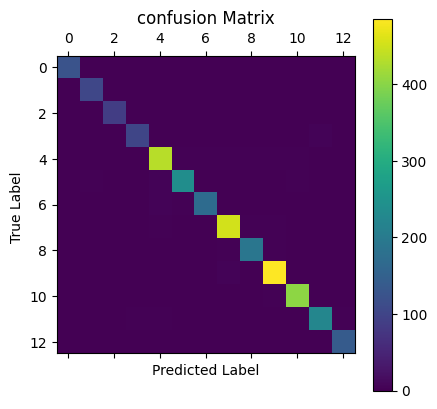

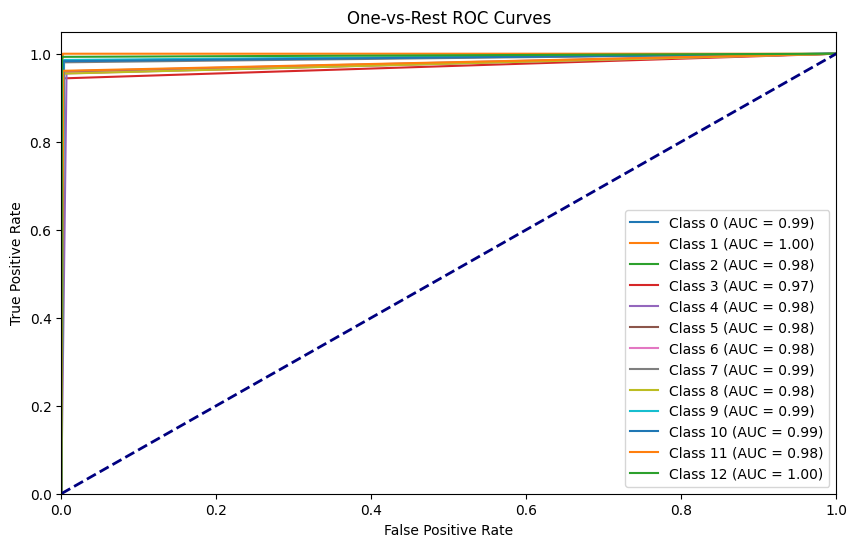

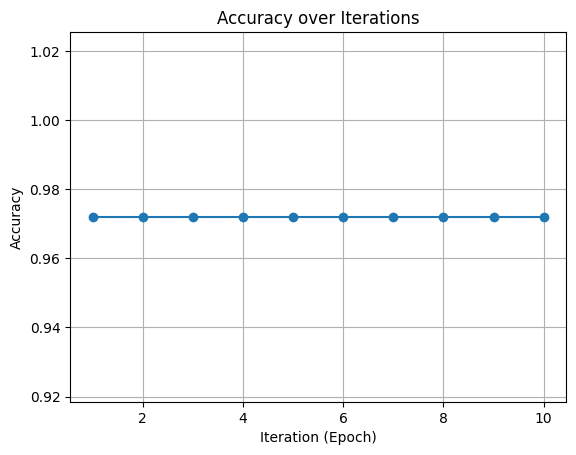

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

precision = precision_score(y_test, ensemble_predictions1, average='weighted')
recall = recall_score(y_test, ensemble_predictions1, average='weighted')
f1 = f1_score(y_test, ensemble_predictions1, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions1)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions1) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions1]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions1)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions1, y_test)
    
    # Make ensemble predictions
    ensemble_predictions1 = meta_learner.predict(combined_predictions1)
    
    # Calculate accuracy
    ensemble_accuracy1 = accuracy_score(y_test, ensemble_predictions1)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy1)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

# Dense+Oct+Dpn

In [41]:
combined_predictions2 = np.concatenate((Dense_predictions,OCTpredictions,Dpn_predictions),axis=1)

In [43]:
meta_learner.fit(combined_predictions2, y_test)

# Make ensemble predictions
ensemble_predictions2 = meta_learner.predict(combined_predictions2)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions2)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9750385208012327


Precision: 0.9750858083149362
Recall: 0.9750385208012327
F1-score: 0.9750092773207426
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       126
           1       0.97      0.99      0.98       103
           2       0.98      0.96      0.97        93
           3       0.98      0.95      0.97       107
           4       0.96      0.98      0.97       452
           5       0.98      0.95      0.97       249
           6       0.96      0.95      0.95       178
           7       0.98      0.97      0.97       461
           8       0.97      0.97      0.97       199
           9       0.98      0.99      0.98       493
          10       0.97      0.99      0.98       411
          11       0.98      0.97      0.98       232
          12       0.98      0.99      0.99       141

    accuracy                           0.98      3245
   macro avg       0.98      0.97      0.97      3245
weighted avg       0.98  

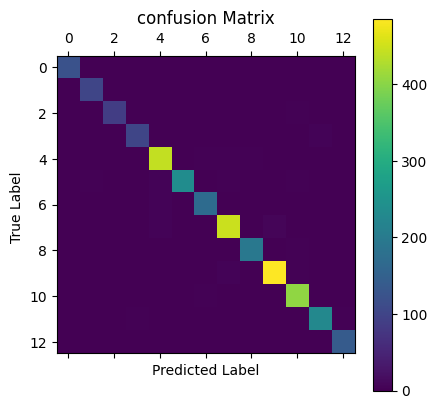

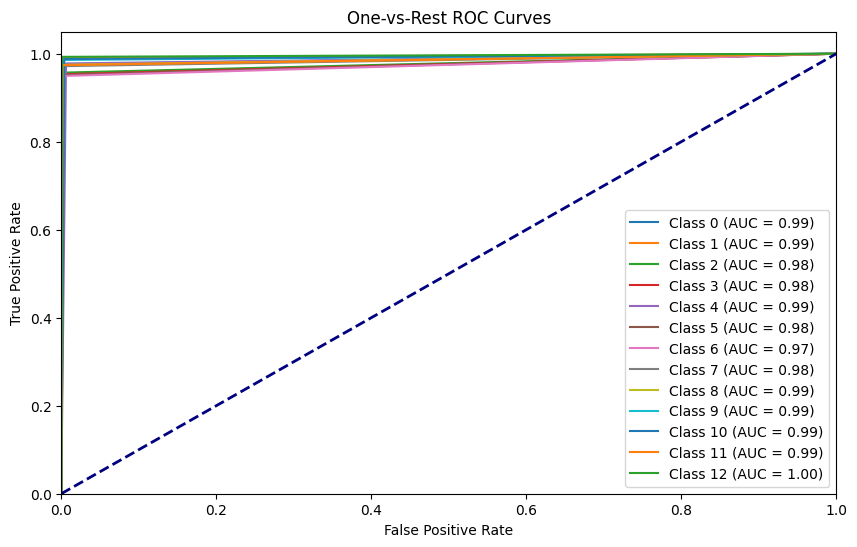

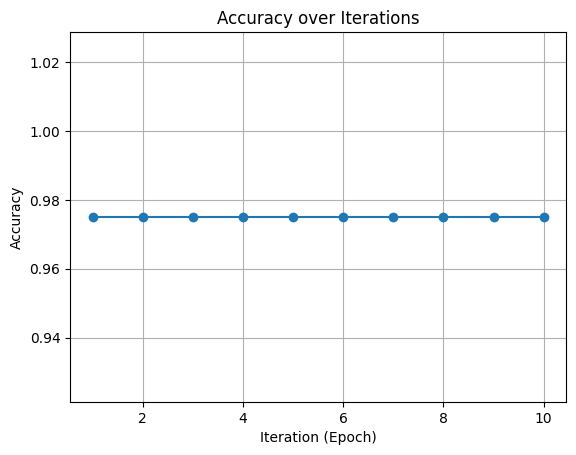

In [44]:
precision = precision_score(y_test, ensemble_predictions2, average='weighted')
recall = recall_score(y_test, ensemble_predictions2, average='weighted')
f1 = f1_score(y_test, ensemble_predictions2, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions2)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions2) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions2]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions2)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions2, y_test)
    
    # Make ensemble predictions
    ensemble_predictions2 = meta_learner.predict(combined_predictions2)
    
    # Calculate accuracy
    ensemble_accuracy2 = accuracy_score(y_test, ensemble_predictions2)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy2)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

# Mobile+Dense+Dpn

In [42]:
combined_predictions3 = np.concatenate((Mobile_predictions,Dense_predictions,Dpn_predictions),axis=1)

In [45]:
meta_learner = LogisticRegression()


meta_learner.fit(combined_predictions3, y_test)

# Make ensemble predictions
ensemble_predictions3 = meta_learner.predict(combined_predictions3)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions3)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9704160246533128


Precision: 0.970529107090763
Recall: 0.9704160246533128
F1-score: 0.9703818268455636
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       126
           1       0.97      0.99      0.98       103
           2       0.99      0.96      0.97        93
           3       0.98      0.93      0.96       107
           4       0.97      0.96      0.96       452
           5       0.98      0.95      0.97       249
           6       0.96      0.96      0.96       178
           7       0.97      0.97      0.97       461
           8       0.95      0.97      0.96       199
           9       0.98      0.99      0.98       493
          10       0.96      0.99      0.97       411
          11       0.98      0.97      0.97       232
          12       0.97      0.99      0.98       141

    accuracy                           0.97      3245
   macro avg       0.97      0.97      0.97      3245
weighted avg       0.97   

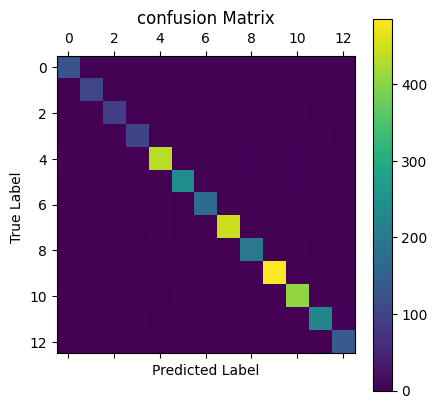

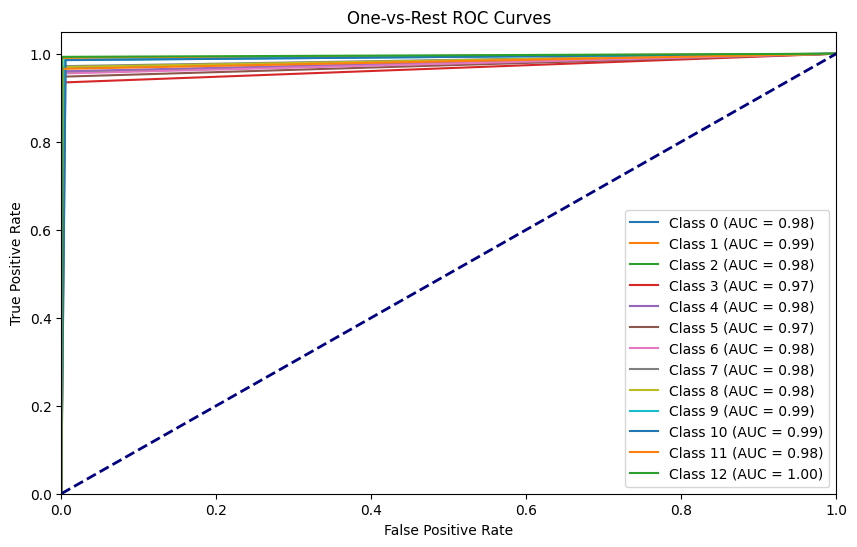

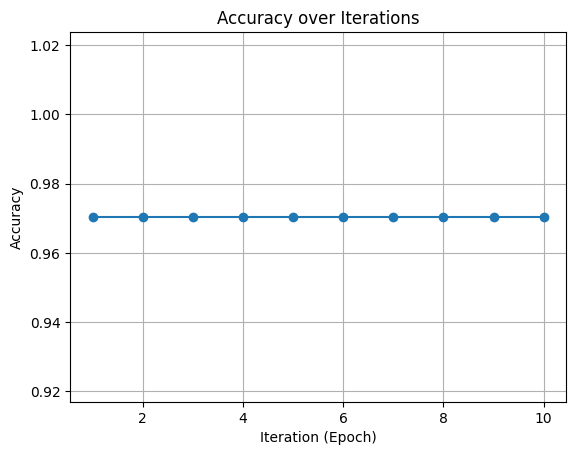

In [46]:
precision = precision_score(y_test, ensemble_predictions3, average='weighted')
recall = recall_score(y_test, ensemble_predictions3, average='weighted')
f1 = f1_score(y_test, ensemble_predictions3, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions3)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions3) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions3]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions3)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions3, y_test)
    
    # Make ensemble predictions
    ensemble_predictions3 = meta_learner.predict(combined_predictions3)
    
    # Calculate accuracy
    ensemble_accuracy3 = accuracy_score(y_test, ensemble_predictions3)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy3)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

# Mobile+Dense+Oct+Dpn

In [47]:
combined_predictions4 = np.concatenate((Mobile_predictions,Dpn_predictions,Dense_predictions,OCTpredictions),axis=1)

In [48]:
meta_learner = LogisticRegression()


meta_learner.fit(combined_predictions4, y_test)

# Make ensemble predictions
ensemble_predictions4 = meta_learner.predict(combined_predictions4)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions4)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9775038520801232


Precision: 0.9775535908916017
Recall: 0.9775038520801232
F1-score: 0.9774845637698725
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       126
           1       0.96      0.99      0.98       103
           2       1.00      0.97      0.98        93
           3       0.97      0.96      0.97       107
           4       0.97      0.97      0.97       452
           5       0.98      0.96      0.97       249
           6       0.96      0.96      0.96       178
           7       0.98      0.98      0.98       461
           8       0.97      0.98      0.98       199
           9       0.98      0.99      0.98       493
          10       0.98      0.99      0.99       411
          11       0.98      0.97      0.98       232
          12       0.97      1.00      0.99       141

    accuracy                           0.98      3245
   macro avg       0.98      0.98      0.98      3245
weighted avg       0.98  

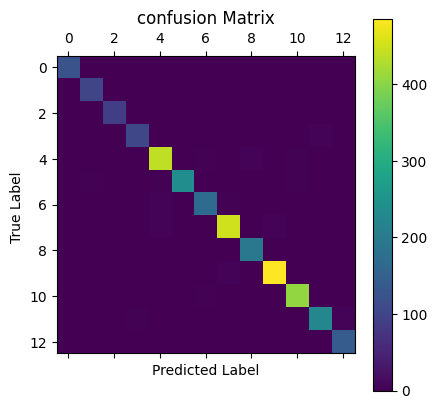

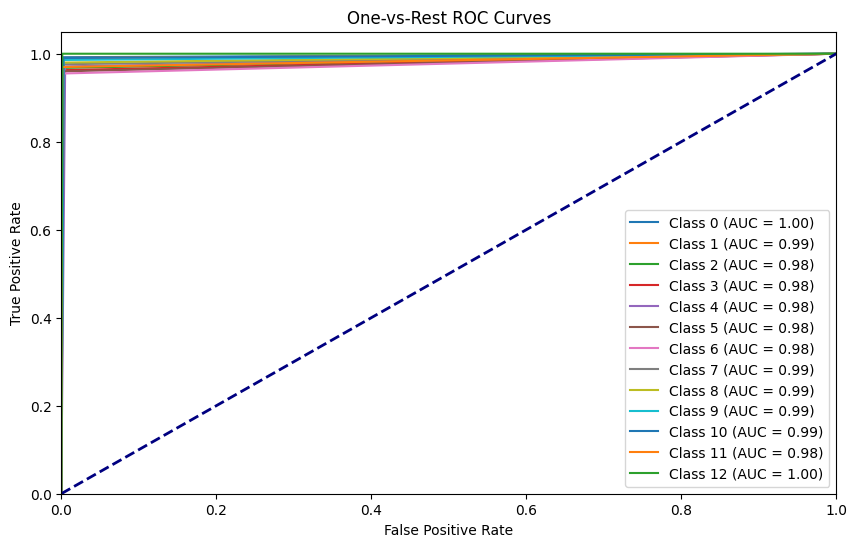

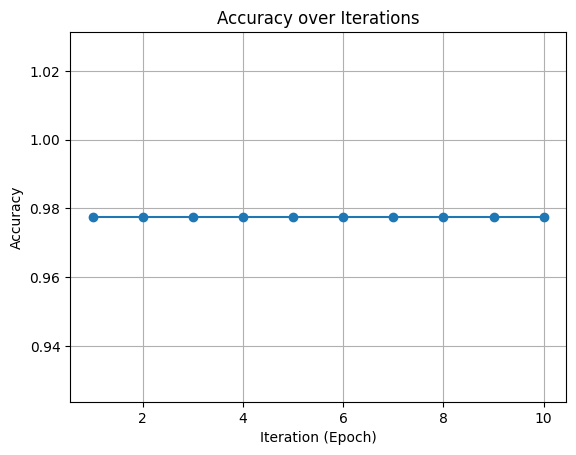

In [49]:
precision = precision_score(y_test, ensemble_predictions4, average='weighted')
recall = recall_score(y_test, ensemble_predictions4, average='weighted')
f1 = f1_score(y_test, ensemble_predictions4, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions4)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions4) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions4]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions4)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions4, y_test)
    
    # Make ensemble predictions
    ensemble_predictions4 = meta_learner.predict(combined_predictions4)
    
    # Calculate accuracy
    ensemble_accuracy4 = accuracy_score(y_test, ensemble_predictions4)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy4)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

# Oct+Dpn

In [50]:
combined_predictions5 = np.concatenate((OCTpredictions,Dpn_predictions),axis=1)

In [53]:
meta_learner = LogisticRegression()


meta_learner.fit(combined_predictions5, y_test)

# Make ensemble predictions
ensemble_predictions5 = meta_learner.predict(combined_predictions5)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions5)
print(f'Ensemble Accuracy: {ensemble_accuracy}')

Ensemble Accuracy: 0.9679506933744222


Precision: 0.9679931068632429
Recall: 0.9679506933744222
F1-score: 0.9679329750082472
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       126
           1       0.96      1.00      0.98       103
           2       0.93      0.94      0.93        93
           3       0.96      0.94      0.95       107
           4       0.96      0.96      0.96       452
           5       0.95      0.96      0.96       249
           6       0.97      0.94      0.95       178
           7       0.97      0.97      0.97       461
           8       0.96      0.95      0.96       199
           9       0.98      0.98      0.98       493
          10       0.98      0.98      0.98       411
          11       0.97      0.96      0.96       232
          12       0.98      0.99      0.99       141

    accuracy                           0.97      3245
   macro avg       0.97      0.97      0.97      3245
weighted avg       0.97  

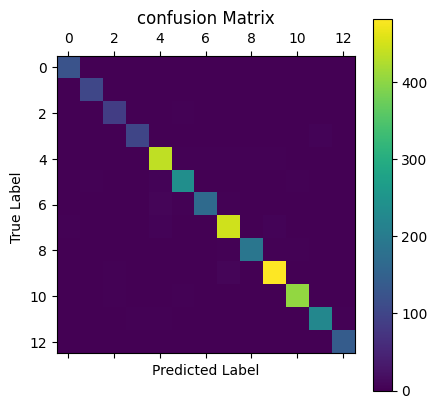

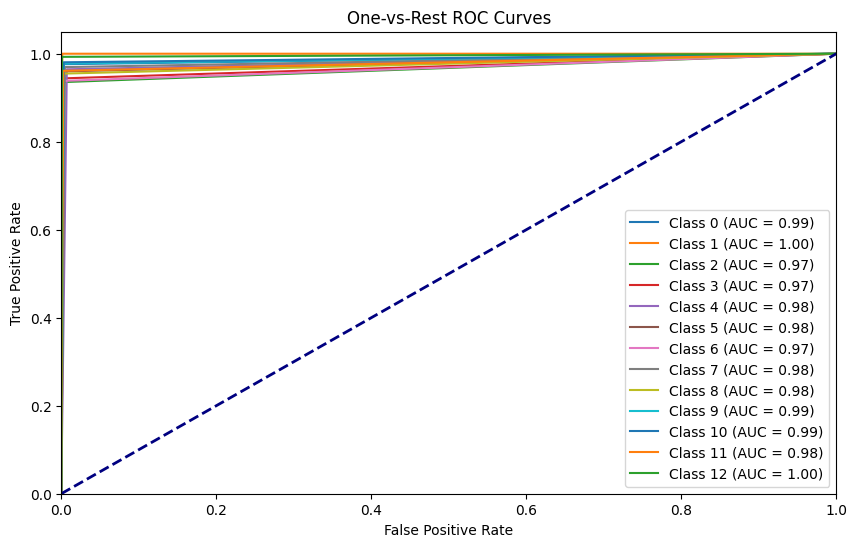

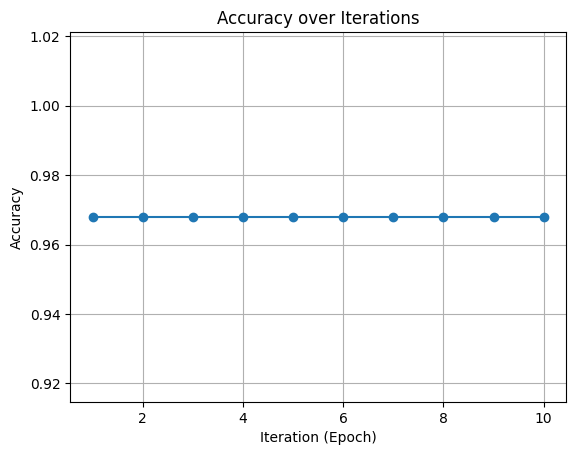

In [54]:
precision = precision_score(y_test, ensemble_predictions5, average='weighted')
recall = recall_score(y_test, ensemble_predictions5, average='weighted')
f1 = f1_score(y_test, ensemble_predictions5, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions5)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions4) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions5]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions5)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions5, y_test)
    
    # Make ensemble predictions
    ensemble_predictions5 = meta_learner.predict(combined_predictions5)
    
    # Calculate accuracy
    ensemble_accuracy5 = accuracy_score(y_test, ensemble_predictions5)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy5)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

# Dense+Dpn


In [51]:
combined_predictions6 = np.concatenate((Dense_predictions,Dpn_predictions),axis=1)

Ensemble Accuracy: 0.9590138674884437
Precision: 0.9591036306477019
Recall: 0.9590138674884437
F1-score: 0.9589465359522326
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       126
           1       0.96      0.99      0.98       103
           2       0.96      0.92      0.94        93
           3       0.96      0.93      0.95       107
           4       0.96      0.95      0.96       452
           5       0.95      0.94      0.94       249
           6       0.95      0.94      0.95       178
           7       0.96      0.96      0.96       461
           8       0.93      0.96      0.95       199
           9       0.96      0.98      0.97       493
          10       0.96      0.98      0.97       411
          11       0.97      0.95      0.96       232
          12       0.96      0.99      0.98       141

    accuracy                           0.96      3245
   macro avg       0.96      0.96      0.

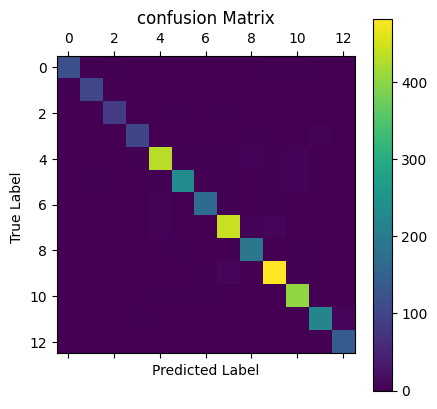

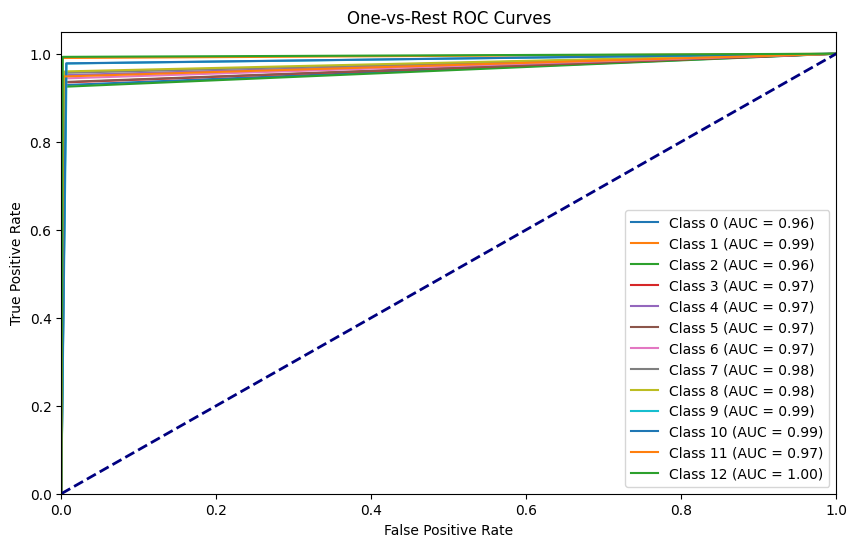

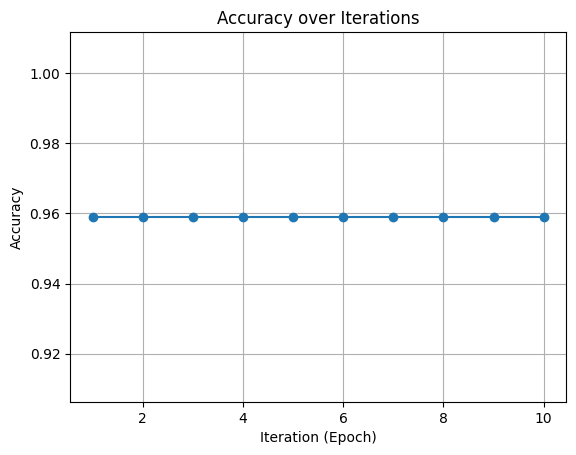

In [55]:
meta_learner.fit(combined_predictions6, y_test)

# Make ensemble predictions
ensemble_predictions6 = meta_learner.predict(combined_predictions6)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions6)
print(f'Ensemble Accuracy: {ensemble_accuracy}')


precision = precision_score(y_test, ensemble_predictions6, average='weighted')
recall = recall_score(y_test, ensemble_predictions6, average='weighted')
f1 = f1_score(y_test, ensemble_predictions6, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions6)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions6) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions6]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions6)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions6, y_test)
    
    # Make ensemble predictions
    ensemble_predictions6 = meta_learner.predict(combined_predictions6)
    
    # Calculate accuracy
    ensemble_accuracy6 = accuracy_score(y_test, ensemble_predictions6)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy6)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()

# Mobile+Dpn

In [52]:
combined_predictions7 = np.concatenate((Mobile_predictions,Dpn_predictions),axis=1)

Ensemble Accuracy: 0.9442218798151002
Precision: 0.9442969337165975
Recall: 0.9442218798151002
F1-score: 0.94416411702442
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       126
           1       0.93      0.97      0.95       103
           2       0.95      0.89      0.92        93
           3       0.91      0.92      0.91       107
           4       0.94      0.94      0.94       452
           5       0.95      0.92      0.93       249
           6       0.94      0.94      0.94       178
           7       0.94      0.95      0.94       461
           8       0.93      0.90      0.91       199
           9       0.96      0.96      0.96       493
          10       0.97      0.97      0.97       411
          11       0.93      0.95      0.94       232
          12       0.95      0.96      0.95       141

    accuracy                           0.94      3245
   macro avg       0.94      0.94      0.94

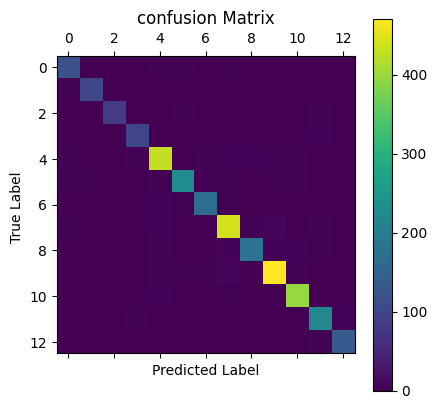

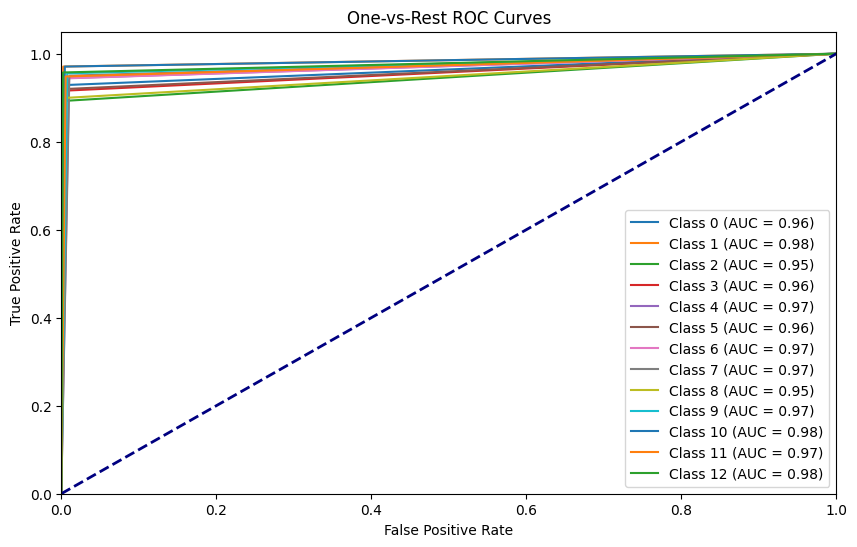

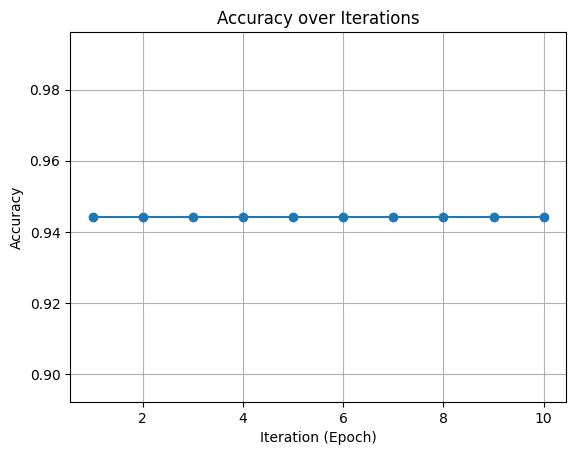

In [56]:
meta_learner.fit(combined_predictions7, y_test)

# Make ensemble predictions
ensemble_predictions7 = meta_learner.predict(combined_predictions7)

# Evaluate ensemble performance
ensemble_accuracy = accuracy_score(y_test, ensemble_predictions7)
print(f'Ensemble Accuracy: {ensemble_accuracy}')


precision = precision_score(y_test, ensemble_predictions7, average='weighted')
recall = recall_score(y_test, ensemble_predictions7, average='weighted')
f1 = f1_score(y_test, ensemble_predictions7, average='weighted')

# Generate a classification report
report = classification_report(y_test, ensemble_predictions7)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print('Classification Report:')
print(report)


num_classes = np.max(ensemble_predictions7) + 1  # Assuming class labels start from 0
y_pred_probs = np.eye(num_classes)[ensemble_predictions7]

# Now, you can calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f'ROC-AUC: {roc_auc}')




from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test,ensemble_predictions7)
print(cm1)
plt.matshow(cm1)
plt.title('confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label ')
plt.colorbar()
plt.show()



from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have trained your logistic regression model and obtained predicted probabilities
# logistic_regression_model = LogisticRegression()
# logistic_regression_model.fit(X_train, y_train)
# y_pred_proba = logistic_regression_model.predict_proba(X_test)

# Compute OvR ROC curve and ROC area for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test == i, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize logistic regression model
meta_learner = LogisticRegression()

# Initialize lists to store accuracy and loss values
accuracy_values = []
num_epochs = 10
# Iterate over iterations (epochs)
for epoch in range(num_epochs):
    # Fit the logistic regression model on the combined predictions
    meta_learner.fit(combined_predictions7, y_test)
    
    # Make ensemble predictions
    ensemble_predictions7 = meta_learner.predict(combined_predictions7)
    
    # Calculate accuracy
    ensemble_accuracy7 = accuracy_score(y_test, ensemble_predictions7)
    
    # Append accuracy to list
    accuracy_values.append(ensemble_accuracy7)

# Plot accuracy over iterations
plt.plot(range(1, num_epochs + 1), accuracy_values, marker='o')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations')
plt.grid(True)
plt.show()